# TP 2 — OpenCV : I/O et transformations

**Objectifs**

- Maîtriser le piège BGR/RGB d'OpenCV.
- Segmenter par teinte dans l'espace HSV.
- Appliquer des transformations géométriques (rotation, perspective) avec `warpAffine` et `warpPerspective`.
- Comparer les filtres OpenCV (`GaussianBlur`, `medianBlur`, `bilateralFilter`).

**Durée indicative : 50 minutes.**

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage import data

# On part d'une image RGB de scikit-image et on simule un flux OpenCV en
# inversant les canaux : c'est exactement ce que renverrait cv2.imread.
img_rgb = data.coffee()
img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

print("shape:", img_bgr.shape, "dtype:", img_bgr.dtype)

shape: (400, 600, 3) dtype: uint8


## Exercice 1 — Piège BGR / RGB

Affichez `img_bgr` directement avec `plt.imshow` puis affichez la version reconvertie en RGB.
Comparez visuellement : pourquoi la première version est-elle « bleutée » ?

**Ajout — charger un vrai fichier avec `cv2.imread`** : enregistrez d'abord `img_rgb` sur disque en utilisant Pillow (par exemple `Image.fromarray(img_rgb).save("coffee.jpg")`), puis relisez-le avec `cv2.imread("coffee.jpg")`. Vérifiez que le tableau retourné est bien en **BGR** en l'affichant tel quel (résultat bleuté) puis en le reconvertissant en RGB. C'est le piège typique du pipeline OpenCV : `imread` charge toujours en BGR, il faut **immédiatement** convertir en RGB avant tout autre traitement.

In [2]:
# TODO : affichage img_bgr (bleuté) puis version reconvertie en RGB

# TODO : sauver img_rgb avec Pillow, recharger avec cv2.imread,
#        observer le BGR puis reconvertir.
# from PIL import Image
# Image.fromarray(img_rgb).save("coffee.jpg")
# img_from_disk = cv2.imread("coffee.jpg")    # BGR
# img_from_disk_rgb = cv2.cvtColor(img_from_disk, cv2.COLOR_BGR2RGB)

## Exercice 2 — Segmentation par teinte (HSV)

1. Convertissez `img_rgb` en HSV avec `cv2.cvtColor(..., cv2.COLOR_RGB2HSV)`.
2. Dans OpenCV, la teinte (`H`) est codée dans `[0, 180]`. Construisez un masque qui sélectionne les pixels « rouge » (H proche de 0 ou de 180) avec une saturation suffisante (`S > 80`).
3. Affichez :
   - l'image originale,
   - le masque,
   - l'image originale × masque (les zones non rouges en noir).

<details>
<summary>💡 Coup de pouce — segmentation par teinte HSV</summary>

**🎯 But :** isoler tous les pixels d'une couleur donnée (ici, rouge) indépendamment de la luminosité, grâce à l'espace HSV.

**Conversion en HSV**

```python
hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
```

⚠️ **Convention OpenCV** : `H ∈ [0, 180]` (entier, demi-cercle pour tenir sur uint8), `S ∈ [0, 255]`, `V ∈ [0, 255]`. C'est **différent de scikit-image** qui code en float [0, 1].

**Le piège du rouge à cheval sur 0/180**

Sur le cercle des teintes 0-360°, le rouge occupe la zone autour de 0° (≡ 360°). En OpenCV [0-180], ça devient **deux zones disjointes** : `[0, 10]` et `[170, 180]`. Il faut donc créer **deux masques** et les combiner :

```python
mask1 = cv2.inRange(hsv, (0, 80, 50),   (10, 255, 255))   # rouges « purs »
mask2 = cv2.inRange(hsv, (170, 80, 50), (180, 255, 255))  # rouges du côté magenta
mask  = mask1 | mask2                                      # union des deux
```

Les triplets sont `(H_min, S_min, V_min)` et `(H_max, S_max, V_max)`. Le `S > 80` élimine les gris (qui ont H proche de 0 par hasard mais aucune saturation).

**Pour d'autres couleurs (vert, bleu, jaune)**, l'intervalle est **continu** (pas de wrap-around) → un seul `inRange` suffit :

```python
mask_bleu = cv2.inRange(hsv, (100, 80, 50), (130, 255, 255))   # bleu : H ≈ 110
mask_vert = cv2.inRange(hsv, (40,  80, 50), (75,  255, 255))   # vert : H ≈ 60
```

**Appliquer le masque pour ne garder que les pixels rouges**

```python
result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
```

`bitwise_and` avec un masque garde l'image originale là où le masque est non-nul, met à 0 ailleurs.

</details>

In [3]:
# TODO

## Exercice 3 — Rotation avec warpAffine

1. Construisez la matrice de rotation de 25° autour du centre de l'image avec `cv2.getRotationMatrix2D`.
2. Appliquez `cv2.warpAffine` pour obtenir l'image tournée. Conservez la même taille de sortie que l'entrée.
3. Affichez côte à côte l'originale et la version tournée.

<details>
<summary>💡 Coup de pouce — rotation avec warpAffine</summary>

**🎯 But :** tourner une image autour d'un point arbitraire en utilisant une matrice 2×3 (6 paramètres affines).

**Construire la matrice de rotation**

```python
h, w = img.shape[:2]
center = (w // 2, h // 2)              # pivot = centre image
M = cv2.getRotationMatrix2D(center, angle=25, scale=1.0)
```

`getRotationMatrix2D` renvoie une **matrice 2×3** :
```
M = [ s·cos(θ)   s·sin(θ)   tx ]
    [ -s·sin(θ)  s·cos(θ)   ty ]
```
- `a, d = s·cos(θ)` → rotation + échelle
- `b, c = ±s·sin(θ)` → cisaillement de rotation
- `tx, ty` calculés pour pivoter autour du `center` choisi

**Appliquer la transformation**

```python
rotated = cv2.warpAffine(img, M, (w, h), borderValue=(255, 255, 255))
```

- Le 3ᵉ argument `(w, h)` est la **taille du canvas de sortie**, qui peut différer de la source.
- `borderValue` = couleur des pixels non couverts par la transformation (sinon noir par défaut).

⚠️ **Piège des coins coupés** : si on garde `(w, h)` identique à l'entrée, les coins de l'image originale sortent du cadre rectangulaire en tournant et sont coupés. Pour préserver tout, il faut **recalculer la taille du canvas** :

```python
cos_a, sin_a = abs(M[0, 0]), abs(M[0, 1])
new_w = int(h * sin_a + w * cos_a)
new_h = int(h * cos_a + w * sin_a)
M[0, 2] += (new_w - w) / 2   # ajuste tx
M[1, 2] += (new_h - h) / 2   # ajuste ty
rotated_full = cv2.warpAffine(img, M, (new_w, new_h), borderValue=(255, 255, 255))
```

</details>

In [4]:
# TODO

## Exercice 4 — Rectification de perspective

On simule une photo prise « de travers » en appliquant à l'image une transformation de perspective connue, puis on demande à l'apprenant de la **rectifier**.

Étapes :

1. Choisissez 4 points sources (les 4 coins de l'image) et 4 points destinations qui simulent une vue en perspective (par exemple en déplaçant les coins).
2. Utilisez `cv2.getPerspectiveTransform` puis `cv2.warpPerspective` pour produire `img_perspective`.
3. **À votre tour** : inversez la transformation pour récupérer une image rectifiée à partir de `img_perspective`, en ne connaissant que les 4 coins du quadrilatère apparent.

<details>
<summary>💡 Coup de pouce — rectification de perspective</summary>

**🎯 But :** « redresser » une image prise de biais (document, panneau) en spécifiant 4 correspondances de points.

**Pourquoi 4 points ?**

Une transformation perspective (homographie) a **8 paramètres indépendants**. Chaque correspondance `(src_i ↔ dst_i)` donne 2 équations (une en x, une en y). 4 points × 2 = 8 équations → système exactement déterminé.

**Définir les 4 points sources**

Les 4 coins de l'image originale (par exemple) :

```python
src = np.float32([[0,     0],
                  [w - 1, 0],
                  [w - 1, h - 1],
                  [0,     h - 1]])
```

⚠️ **Doit être `float32`**, pas `int` — OpenCV plantera sinon.

**Définir les 4 points cibles**

Pour simuler une perspective (envoyer les coins vers des positions désaxées) :

```python
dst = np.float32([[50, 30], [w - 80, 60], [w - 40, h - 50], [80, h - 20]])
```

Les 4 coins sont déplacés à des positions arbitraires : ça simule une photo prise de biais.

**Calculer et appliquer**

```python
M = cv2.getPerspectiveTransform(src, dst)
img_perspective = cv2.warpPerspective(img_rgb, M, (w, h))
```

`M` est cette fois **3×3** (homographie), pas 2×3 comme l'affine.

**Inverser la transformation (rectifier)**

Deux méthodes équivalentes :

```python
# Méthode 1 : recalculer avec src et dst échangés
M_inv = cv2.getPerspectiveTransform(dst, src)
img_rectified = cv2.warpPerspective(img_perspective, M_inv, (w, h))

# Méthode 2 : inverser la matrice M
_, M_inv = cv2.invert(M)
img_rectified = cv2.warpPerspective(img_perspective, M_inv, (w, h))
```

En pratique, méthode 1 est plus lisible (on raisonne directement avec les coordonnées).

</details>

Text(0.5, 1.0, 'Image distordue')

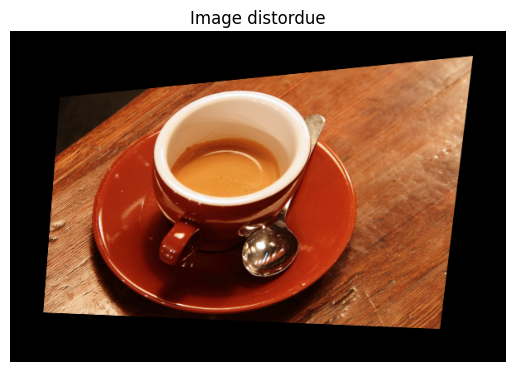

In [5]:
H, W = img_rgb.shape[:2]

src = np.float32([[0, 0], [W, 0], [W, H], [0, H]])
dst = np.float32([[60, 80], [W - 40, 30], [W - 80, H - 40], [40, H - 60]])

M = cv2.getPerspectiveTransform(src, dst)
img_perspective = cv2.warpPerspective(img_rgb, M, (W, H))

plt.imshow(img_perspective)
plt.axis("off")
plt.title("Image distordue")

In [6]:
# TODO : récupérer une image rectifiée à partir de img_perspective et de dst.

## Exercice 5 — Comparaison de filtres OpenCV

Ajoutez du bruit gaussien à `img_rgb` (`img_rgb + 25 * randn`, clip dans `[0, 255]`, cast uint8).

Appliquez les trois filtres OpenCV suivants et affichez les résultats côte à côte :

- `cv2.GaussianBlur(noisy, (5, 5), 0)`
- `cv2.medianBlur(noisy, 5)`
- `cv2.bilateralFilter(noisy, 9, 75, 75)`

Discutez : lequel préserve le mieux les détails ?

<details>
<summary>💡 Coup de pouce — comparaison de filtres OpenCV</summary>

**🎯 But :** observer concrètement les **effets visuels différents** de 3 filtres de débruitage sur la même image bruitée.

**Ajouter du bruit gaussien synthétique**

```python
noise = 25 * np.random.randn(*img_rgb.shape)
noisy = np.clip(img_rgb + noise, 0, 255).astype(np.uint8)
```

- `np.random.randn(*shape)` = bruit gaussien N(0, 1) de la bonne forme.
- `* 25` = écart-type 25 (intensité visible mais pas extrême).
- `np.clip` ramène les pixels dans [0, 255] (sinon overflow).
- `.astype(np.uint8)` car les filtres OpenCV attendent uint8.

**Les 3 filtres**

Chacun a une signature différente :

```python
img_gauss = cv2.GaussianBlur(noisy, (5, 5), 0)
img_med   = cv2.medianBlur(noisy, 5)
img_bilat = cv2.bilateralFilter(noisy, d=9, sigmaColor=75, sigmaSpace=75)
```

- **`GaussianBlur((kx, ky), sigma)`** — kernel impair `(5, 5)`. Si `sigma=0`, OpenCV le déduit du kernel.
- **`medianBlur(img, ksize)`** — un entier impair (5 = fenêtre 5×5). Pas de kernel custom.
- **`bilateralFilter(img, d, sigmaColor, sigmaSpace)`** — `d` = diamètre du voisinage en pixels (9 = bon défaut). Les deux sigmas contrôlent respectivement la tolérance en intensité et en distance.

**Ce que vous devriez observer**

| Filtre | Comportement | Bords | Texture fine |
|---|---|---|---|
| Gaussien | Lisse tout uniformément | ❌ floutés | ❌ perdue |
| Médian | Excellent sur impulsions | ✅ préservés | ❌ aplatie |
| Bilatéral | Sélectif | ✅ très bien préservés | ⚠️ partiel |

C'est le bilatéral qu'on choisit pour une « belle » photo : il enlève le bruit en gardant les détails. Le médian sauve les images avec sel-poivre. Le gaussien sert surtout en prétraitement avant détection de bords.

</details>

In [7]:
# TODO